In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
#!wget $data

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


# Data Preparation

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
# We can see that TotalCharges is a str but it should be an int. So we will convert it.

In [9]:
pd.to_numeric(df.TotalCharges, errors='coerce')
#In pd.to_numeric(), coerce means:
#If a value cannot be converted to a number, replace it with NaN instead of throwing an error.

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [10]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')

In [11]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [12]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [13]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                   str
dtype: object

In [14]:
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

In [15]:
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [16]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [17]:
df.churn

0        no
1        no
2       yes
3        no
4       yes
       ... 
7038     no
7039     no
7040     no
7041    yes
7042     no
Name: churn, Length: 7043, dtype: str

In [18]:
df.churn = (df.churn == 'yes').astype(int)

In [19]:
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [20]:
df.isnull().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [21]:
df.totalcharges = df.totalcharges.fillna(0)

# Setting Up Validation Framework

* ### Splitting this dataset into training/validation/test using Scikit-Learn

In [22]:
from sklearn.model_selection import train_test_split

#### train_test_split is a function that breaks the dataset into two parts, training and test. But we will split it more for validation.

In [23]:
df_full_train, df_test = train_test_split(df, test_size= 0.2, random_state= 1)

In [24]:
len(df_full_train), len(df_test)

(5634, 1409)

#### Now our data is split into 80:20, but from that 80 percent we need to make it 60:20. 20% of 80% is 25%.

In [25]:
df_train, df_val = train_test_split(df_full_train, test_size= 0.25, random_state= 1)

In [26]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [27]:
df_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
3897,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,...,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15,0
1980,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,...,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55,0
6302,9250-wypll,female,0,no,no,5,yes,yes,fiber_optic,no,...,no,no,no,no,month-to-month,no,electronic_check,75.55,413.65,1
727,6786-obwqr,female,0,yes,yes,5,yes,no,fiber_optic,no,...,no,no,yes,no,month-to-month,yes,electronic_check,80.85,356.10,0
5104,1328-euzhc,female,0,yes,no,18,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.10,370.50,0


In [28]:
df_full_train = df_full_train.reset_index(drop= True)
df_train = df_train.reset_index(drop= True)
df_val = df_val.reset_index(drop= True)
df_test = df_test.reset_index(drop= True)

In [29]:
df_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,...,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15,0
1,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,...,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55,0
2,9250-wypll,female,0,no,no,5,yes,yes,fiber_optic,no,...,no,no,no,no,month-to-month,no,electronic_check,75.55,413.65,1
3,6786-obwqr,female,0,yes,yes,5,yes,no,fiber_optic,no,...,no,no,yes,no,month-to-month,yes,electronic_check,80.85,356.10,0
4,1328-euzhc,female,0,yes,no,18,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.10,370.50,0


In [30]:
y_full_train = df_full_train['churn'].values
y_train = df_train['churn'].values
y_val = df_val['churn'].values
y_test = df_test['churn'].values


In [31]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [32]:
df_train.head().T

,0,1,2,3,4
customerid,8015-ihcgw,1960-uycnn,9250-wypll,6786-obwqr,1328-euzhc
gender,female,male,female,female,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,yes,yes
dependents,yes,no,no,yes,no
tenure,72,10,5,5,18
phoneservice,yes,yes,yes,yes,yes
multiplelines,yes,yes,yes,no,no
internetservice,fiber_optic,fiber_optic,fiber_optic,fiber_optic,no
onlinesecurity,yes,no,no,no,no_internet_service


# Exploratory Data Analysis

* #### Check missing values.
* #### Look at target value(churn).
* #### Look at numerical and categorical variables.

In [33]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [34]:
np.unique(y_full_train, return_counts= True)
# Basically 0 = 73%, 1 = 27%

(array([0, 1]), array([4113, 1521]))

In [35]:
global_churn_rate = y_full_train.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [36]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [37]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [38]:
df_full_train.dtypes.index

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [39]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
          'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [40]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [41]:
df[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

# Feature importance: Churn Rate and Risk Ratio

#### Feature importance analysis(part of EDA) - Identifying which features affect our target variable.

* #### Churn rate
* #### Risk ratio
* #### Mutual information

#### Churn rate and Risk ratio

#### Refer notebook for notes on these concepts.

In [42]:
global_churn_rate = df_full_train.churn.mean()
global_churn_rate

np.float64(0.26996805111821087)

In [43]:
churn_female = df_full_train[df_full_train['gender'] == 'female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [44]:
churn_male = df_full_train[df_full_train['gender'] == 'male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [45]:
churn_partner = df_full_train[df_full_train['partner'] == 'yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [46]:
churn_no_partner = df_full_train[df_full_train['partner'] == 'no'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [47]:
df_full_train.groupby('gender').churn.mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [48]:
df_full_train.groupby('gender').churn.agg(['mean', 'count'])
# This creates a dataframe for us that divides the data into caregories, and apply functions on it.

,mean,count
gender,,
female,0.276824,2796
male,0.263214,2838


In [49]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['Diff'] = global_churn_rate - df_group['mean']
df_group['Risk'] = df_group['mean'] / global_churn_rate

df_group

,mean,count,Diff,Risk
gender,,,,
female,0.276824,2796,-0.006856,1.025396
male,0.263214,2838,0.006755,0.974980


#### Let's do this for all categorical variables.

In [50]:
from IPython.display import display

In [51]:
for c in categorical:
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['Diff'] = global_churn_rate - df_group['mean']
    df_group['Risk'] = df_group['mean'] / global_churn_rate
    print(c)
    display(df_group)
    print()
    print()

gender


,mean,count,Diff,Risk
gender,,,,
female,0.276824,2796,-0.006856,1.025396
male,0.263214,2838,0.006755,0.974980




seniorcitizen


,mean,count,Diff,Risk
seniorcitizen,,,,
0,0.242270,4722,0.027698,0.897403
1,0.413377,912,-0.143409,1.531208




partner


,mean,count,Diff,Risk
partner,,,,
no,0.329809,2932,-0.059841,1.221659
yes,0.205033,2702,0.064935,0.759472




dependents


,mean,count,Diff,Risk
dependents,,,,
no,0.313760,3968,-0.043792,1.162212
yes,0.165666,1666,0.104302,0.613651




phoneservice


,mean,count,Diff,Risk
phoneservice,,,,
no,0.241316,547,0.028652,0.893870
yes,0.273049,5087,-0.003081,1.011412




multiplelines


,mean,count,Diff,Risk
multiplelines,,,,
no,0.257407,2700,0.012561,0.953474
no_phone_service,0.241316,547,0.028652,0.893870
yes,0.290742,2387,-0.020773,1.076948




internetservice


,mean,count,Diff,Risk
internetservice,,,,
dsl,0.192347,1934,0.077621,0.712482
fiber_optic,0.425171,2479,-0.155203,1.574895
no,0.077805,1221,0.192163,0.288201




onlinesecurity


,mean,count,Diff,Risk
onlinesecurity,,,,
no,0.420921,2801,-0.150953,1.559152
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.153226,1612,0.116742,0.567570




onlinebackup


,mean,count,Diff,Risk
onlinebackup,,,,
no,0.404323,2498,-0.134355,1.497672
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.217232,1915,0.052736,0.804660




deviceprotection


,mean,count,Diff,Risk
deviceprotection,,,,
no,0.395875,2473,-0.125907,1.466379
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.230412,1940,0.039556,0.853480




techsupport


,mean,count,Diff,Risk
techsupport,,,,
no,0.418914,2781,-0.148946,1.551717
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.159926,1632,0.110042,0.592390




streamingtv


,mean,count,Diff,Risk
streamingtv,,,,
no,0.342832,2246,-0.072864,1.269897
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.302723,2167,-0.032755,1.121328




streamingmovies


,mean,count,Diff,Risk
streamingmovies,,,,
no,0.338906,2213,-0.068938,1.255358
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.307273,2200,-0.037305,1.138182




contract


,mean,count,Diff,Risk
contract,,,,
month-to-month,0.431701,3104,-0.161733,1.599082
one_year,0.120573,1186,0.149395,0.446621
two_year,0.028274,1344,0.241694,0.104730




paperlessbilling


,mean,count,Diff,Risk
paperlessbilling,,,,
no,0.172071,2313,0.097897,0.637375
yes,0.338151,3321,-0.068183,1.252560




paymentmethod


,mean,count,Diff,Risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,0.101797,0.622928
credit_card_(automatic),0.164339,1217,0.105630,0.608733
electronic_check,0.455890,1893,-0.185922,1.688682
mailed_check,0.193870,1305,0.076098,0.718121


### Mutual Information

#### Go to this link for proper explanation. - https://www.youtube.com/watch?v=eJIp_mgVLwE&t=379s

In [52]:
from sklearn.metrics import mutual_info_score

In [53]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

0.0001174846211139946

#### Similarly we can apply this function to all the categoical columns.

In [54]:
def mutual_info_churn_score(column):
    return mutual_info_score(column, df_full_train.churn)

In [55]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending = False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

#### Now we can see the mutual information of each categorical variable with churn.

### Correlation

#### For further concepts, read this concepts for better understanding.

#### Mean, Variance and Standard Deviation - https://www.youtube.com/watch?v=SzZ6GpcfoQY

#### Covariance - https://youtu.be/qtaqvPAeEJY

#### Correlation - https://youtu.be/xZ_z8KWkhXE

In [56]:
df_full_train[numerical]

,tenure,monthlycharges,totalcharges
0,12,19.70,258.35
1,42,73.90,3160.55
2,71,65.15,4681.75
3,71,85.45,6300.85
4,30,70.40,2044.75
...,...,...,...
5629,9,100.50,918.60
5630,60,19.95,1189.90
5631,28,105.70,2979.50
5632,2,54.40,114.10


In [57]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

# One-hot Encoding

#### Using Scikit-Learn to encode categorical features.

In [58]:
from sklearn.feature_extraction import DictVectorizer

#### Dictvectorizer uses dictionaries as input to encode it.
#### Let us see an example.

In [59]:
df_train[['gender', 'contract']].iloc[:100].to_dict(orient='records')
# If we don't specify orient, it will make dictionaries column wise.

[{'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'one_year'},
 {'gender': 'male', 'contract': 'two_year'},
 {

In [60]:
dicts = df_train[['gender', 'contract']].iloc[:100].to_dict(orient='records')

In [61]:
dv = DictVectorizer(sparse = False)
# We don't want it to make sparse matrix of the encoded values.

In [62]:
dv.fit(dicts)
# It learns about the features.

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [63]:
dv.feature_names_

['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'gender=female',
 'gender=male']

In [64]:
dv.transform(dicts)
# It actually works on the data here.

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0.

#### DictVectorizer is actually pretty smart, if you give it numerical variable, it will not encode it.

In [65]:
dicts = df_train[['gender', 'contract', 'tenure']].iloc[:100].to_dict(orient='records')

In [66]:
dv.fit(dicts)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [67]:
dv.transform(dicts)

array([[ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 10.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 0.,  0.,  1.,  1.,  0., 18.],
       [ 1.,  0.,  0.,  0.,  1.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  1.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  1.,  0.,  6.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 17.],
       [ 0.,  0.,  1.,  1.,  0., 66.],
       [ 1.,  0.,  0.,  1.,  0.,  2.],
       [ 1.,  0.,  0.,  1.,  0.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  1.,  0., 71.],
       [ 1.,  0.,  0.,  1.,  0., 32.],
       [ 0.,  1.,  0.,  0.,  1., 53.],
       [ 0.,  0.,  1.,  0.,  1., 56.],
       [ 1.,  0.,  0.,  0.,  1., 61.],
       [ 0.,  1.,  0.,  1.,  0., 41.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0.,  3.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  0

#### Now, let's work on our training data.

In [68]:
train_dicts = df_train[categorical + numerical].to_dict(orient= 'records')

#### We can do fit and transform into a single function called fit_transform.

In [69]:
X_train = dv.fit_transform(train_dicts)
X_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]], shape=(4225, 45))

In [70]:
list(X_train[0])

[np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(115.5),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(72.0),
 np.float64(8425.15)]

#### Similarly, we'll do encoding of validation data.

In [71]:
val_dicts = df_val[categorical + numerical].to_dict(orient= 'records')

In [72]:
X_val = dv.transform(val_dicts)
# We don't need to fit it again, because it knows about the variables.
X_val

array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 7.1000e+01,
        4.9734e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0750e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0350e+01],
       ...,
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 1.8000e+01,
        1.0581e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        9.3300e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 3.0000e+00,
        2.9285e+02]], shape=(1409, 45))

# Logictic Regression

#### https://youtu.be/yIYKR4sgzI8

#### https://youtube.com/playlist?list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe&si=Ak5EHd2EJeF0znMN

#### https://www.youtube.com/watch?v=3bvM3NyMiE0

#### https://www.youtube.com/watch?v=EKm0spFxFG4

#### Instead of the summation in linear regression, the logistic regression uses Sigmoid function in the formula.

#### Let's use Scikit Learn to implement Logistic Regression.

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
model = LogisticRegression()

In [75]:
# Let's train the model
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [76]:
# It's the bias term.
model.intercept_[0]

np.float64(-0.1109287445794238)

In [77]:
model.coef_
# These are the weights given by the model.

array([[ 5.64103371e-01, -1.53734240e-01, -5.19155705e-01,
        -1.32977867e-02, -9.54887881e-02,  7.12426185e-02,
        -9.82489918e-02, -8.17802015e-02, -3.25289351e-02,
        -7.62576397e-02, -3.53663464e-01,  3.43125881e-01,
        -9.82489918e-02,  2.07687059e-03, -2.50595389e-01,
         1.62031166e-01, -2.02223516e-02,  6.55022995e-02,
        -9.82489918e-02, -7.60398825e-02,  2.50662431e-01,
        -9.82489918e-02, -2.61200014e-01, -2.27866111e-01,
         1.19079536e-01, -1.21248632e-01,  1.24620575e-02,
        -9.49748454e-02, -3.02471209e-02,  4.49016038e-02,
        -2.84662123e-02,  1.62031166e-01, -2.70817741e-01,
         2.20640249e-01, -9.73790420e-02, -9.82489918e-02,
         8.68414590e-02, -4.99556591e-02, -9.82489918e-02,
         3.94180762e-02,  1.94389753e-01, -9.82489918e-02,
        -2.04927336e-01, -7.21547204e-02,  4.34177467e-04]])

In [78]:
np.column_stack((model.predict(X_train)[:10],model.predict_proba(X_train)[:10]))
# predict_proba has two columns, it has soft predictions, it has scores, probability of being 0 or churn and probability of being 1 or churn.

array([[0.        , 0.91088688, 0.08911312],
       [1.        , 0.33128828, 0.66871172],
       [1.        , 0.36229559, 0.63770441],
       [1.        , 0.30812474, 0.69187526],
       [0.        , 0.96176852, 0.03823148],
       [0.        , 0.52720248, 0.47279752],
       [1.        , 0.26711199, 0.73288801],
       [1.        , 0.30775679, 0.69224321],
       [0.        , 0.99845573, 0.00154427],
       [1.        , 0.37117674, 0.62882326]])

#### Since we have trained our model on training data, let's see how it performs against validation data.

In [79]:
y_pred = model.predict_proba(X_val)[:,1]
y_pred

array([0.00786347, 0.20992803, 0.2237105 , ..., 0.15014869, 0.77668113,
       0.81035774], shape=(1409,))

In [80]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [81]:
# We also have y_val from our data.
(churn_decision == y_val).mean()
# It means that our model is 80% correct.

np.float64(0.801277501774308)

In [82]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype('int')
df_pred['actual'] = y_val
df_pred['correct'] = df_pred['prediction'] == df_pred['actual']

df_pred

,probability,prediction,actual,correct
0,0.007863,0,0,True
1,0.209928,0,0,True
2,0.223710,0,0,True
3,0.561123,1,1,True
4,0.219586,0,0,True
...,...,...,...,...
1404,0.297790,0,0,True
1405,0.035463,0,1,False
1406,0.150149,0,0,True
1407,0.776681,1,1,True


In [83]:
# Here we can see that when we use mean() function on boolean data, it automatically converts it to int and then finds mean.
df_pred.correct.mean()

np.float64(0.801277501774308)

# Model Interpretation

#### https://youtu.be/OUrlxnUAAEA

# Using the Model

#### Let's train the model with full data and then test it against the testing data.

In [84]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

#### Now, let's encode the data.

In [85]:
dv = DictVectorizer(sparse = False)

In [86]:
X_full_train = dv.fit_transform(dicts_full_train)

In [87]:
X_full_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 2.58350e+02],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.20000e+01, 3.16055e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 4.68175e+03],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.80000e+01, 2.97950e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.00000e+00, 1.14100e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        1.60000e+01, 1.11485e+03]], shape=(5634, 45))

In [88]:
dv.feature_names_

['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'dependents=no',
 'dependents=yes',
 'deviceprotection=no',
 'deviceprotection=no_internet_service',
 'deviceprotection=yes',
 'gender=female',
 'gender=male',
 'internetservice=dsl',
 'internetservice=fiber_optic',
 'internetservice=no',
 'monthlycharges',
 'multiplelines=no',
 'multiplelines=no_phone_service',
 'multiplelines=yes',
 'onlinebackup=no',
 'onlinebackup=no_internet_service',
 'onlinebackup=yes',
 'onlinesecurity=no',
 'onlinesecurity=no_internet_service',
 'onlinesecurity=yes',
 'paperlessbilling=no',
 'paperlessbilling=yes',
 'partner=no',
 'partner=yes',
 'paymentmethod=bank_transfer_(automatic)',
 'paymentmethod=credit_card_(automatic)',
 'paymentmethod=electronic_check',
 'paymentmethod=mailed_check',
 'phoneservice=no',
 'phoneservice=yes',
 'seniorcitizen',
 'streamingmovies=no',
 'streamingmovies=no_internet_service',
 'streamingmovies=yes',
 'streamingtv=no',
 'streamingtv=no_internet_servic

In [89]:
model = LogisticRegression()

In [90]:
model.fit(X_full_train, y_full_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Accuracy and Dummy Model

* #### Evaluate the model on different thresholds.

* #### Check the accuracy of dummy baselines.

In [91]:
y_pred = model.predict_proba(X_val)[:,1]

In [92]:
churn_decision = (y_pred >= 0.5)

In [93]:
(churn_decision == y_val).mean()

np.float64(0.8041163946061036)

#### Here we have 80% accuracy with 0.5 as our threshold on validation data.

#### Let's see how it performs with different threshold values.

#### For doing the same as we did above, we will use Scikit-Learn.

In [94]:
from sklearn.metrics import accuracy_score

In [95]:
thresholds = np.linspace(0, 1, 21)

In [96]:
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [97]:
scores = []
for t in thresholds:
    score = accuracy_score(y_val, (y_pred >= t))
    scores.append(score)
    print(f'{t:.2f} {score:.3f}')

0.00 0.274
0.05 0.503
0.10 0.599
0.15 0.664
0.20 0.725
0.25 0.749
0.30 0.766
0.35 0.776
0.40 0.794
0.45 0.796
0.50 0.804
0.55 0.815
0.60 0.806
0.65 0.788
0.70 0.778
0.75 0.745
0.80 0.737
0.85 0.727
0.90 0.726
0.95 0.726
1.00 0.726


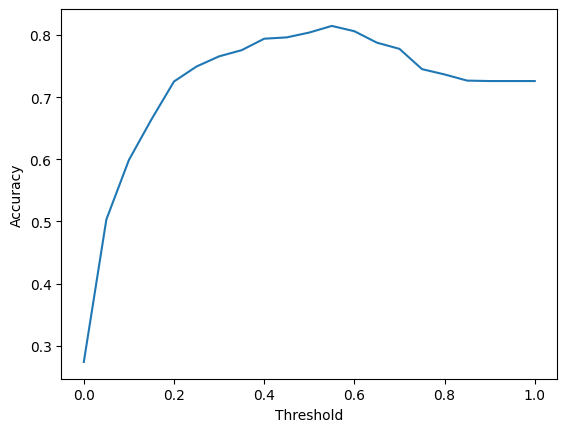

In [98]:
sns.lineplot(x=thresholds, y=scores)

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()

#### The best threshold is 0.55. We can see a peak in the graph too.

#### We can also see that after 0.9, the accuracy remains same. This means that if we considered all of the customers as not churning, we would be only 8% wrong

#### If we see the validation data, only 27% people had churned. Out of that 27% our model works right 80% of the time

In [99]:
from collections import Counter

In [100]:
Counter(y_val)

Counter({np.int64(0): 1023, np.int64(1): 386})

#### The ratio of people churing is 1:3

In [101]:
round(y_val.mean(),2)

np.float64(0.27)

#### Therefore, if we consider that everyone is churning,i.e. threshold = 1. Our dummy model is 73% accurate. And our actual model is 80% accurate with a threshold of 0.5.

# Confusion Matrix

#### https://www.youtube.com/watch?v=Kdsp6soqA7o&t=1s

In [102]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [103]:
t= 0.55 # Why 0.55? Because we saw that our model was more accurate at this threshold value.
predicted_positive = (y_pred >= t)
predicted_negative = (y_pred < t)

In [104]:
# Now we will use bitwise operator to find the values of confusion matrix.
true_positives = (actual_positive & predicted_positive).sum()
true_negatives = (actual_negative & predicted_negative).sum()
false_positives = (actual_negative & predicted_positive).sum()
false_negatives = (actual_positive & predicted_negative).sum()

In [105]:
print(f'tp:{true_positives} \ntn:{true_negatives}\nfp:{false_positives}\nfn:{false_negatives}')

tp:197 
tn:951
fp:72
fn:189


In [106]:
confusion_matrix = np.array([
    [true_positives, false_positives],
    [false_negatives, true_negatives]
])
confusion_matrix

array([[197,  72],
       [189, 951]])

In [107]:
(confusion_matrix/confusion_matrix.sum()).round(2)

array([[0.14, 0.05],
       [0.13, 0.67]])

#### We know that our model is 81% percent accurate.
#### Through confusion matrix, we got a clear picture.
#### **Accuracy(81%) = tp(14%) + tn(67%)**

# Precision and Recall

#### https://youtu.be/qWfzIYCvBqo

In [108]:
precision = true_positives / (true_positives + false_positives)
precision
# precision = total_apples_correct / total_apple_side_observations.

np.float64(0.7323420074349443)

In [109]:
true_positives

np.int64(197)

In [110]:
true_positives + false_positives

np.int64(269)

#### Therefore our precision is 73% for churn prediction.

In [111]:
recall = true_positives / (true_positives + false_negatives)
recall
# Recall is total_apples_correct / total_actual_apples

np.float64(0.5103626943005182)

#### And our recall is 51%

#### Remember this:
#### First column of confusion matrix can help us calculate recall.
#### First row of confusion matrix can help us calculate precision.

# ROC and AUC

#### https://youtu.be/4jRBRDbJemM

#### True positvity rate (Sensitivity) and recall are same metrics.
#### False positive rate = 1 - Specificity = Can be calculated from second column of the confusion matrix.

#### Btw specificity is also known as True negativity rate. 
#### True negativity rate = TN / TN + FP

#### ROC graph has True positivity rate on y-ais and False positivity rate on x-axis.

#### The ROC graph summarizes all the confusion matrics that each threshold produced.

In [112]:
# Let's first calculate TRP and FRP of our data.

In [113]:
tpr = true_positives / (true_positives + false_negatives)
tpr

np.float64(0.5103626943005182)

In [114]:
fpr = false_positives / (false_positives + true_negatives)
fpr

np.float64(0.07038123167155426)

In [115]:
# Now, let's calculate TPR and FPR for different threshold values.

thresholds = np.linspace(0, 1, 101)
scores = []

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predicted_positive = (y_pred >= t)
    predicted_negative = (y_pred < t)

    
    true_positives = (actual_positive & predicted_positive).sum()
    true_negatives = (actual_negative & predicted_negative).sum()
    false_positives = (actual_negative & predicted_positive).sum()
    false_negatives = (actual_positive & predicted_negative).sum()

    scores.append((t, true_positives, false_positives, false_negatives, true_negatives))

In [116]:
scores

[(np.float64(0.0), np.int64(386), np.int64(1023), np.int64(0), np.int64(0)),
 (np.float64(0.01), np.int64(385), np.int64(924), np.int64(1), np.int64(99)),
 (np.float64(0.02), np.int64(384), np.int64(843), np.int64(2), np.int64(180)),
 (np.float64(0.03), np.int64(383), np.int64(775), np.int64(3), np.int64(248)),
 (np.float64(0.04), np.int64(382), np.int64(728), np.int64(4), np.int64(295)),
 (np.float64(0.05), np.int64(379), np.int64(693), np.int64(7), np.int64(330)),
 (np.float64(0.06), np.int64(377), np.int64(666), np.int64(9), np.int64(357)),
 (np.float64(0.07), np.int64(373), np.int64(637), np.int64(13), np.int64(386)),
 (np.float64(0.08), np.int64(370), np.int64(605), np.int64(16), np.int64(418)),
 (np.float64(0.09), np.int64(370), np.int64(576), np.int64(16), np.int64(447)),
 (np.float64(0.1), np.int64(367), np.int64(546), np.int64(19), np.int64(477)),
 (np.float64(0.11), np.int64(366), np.int64(527), np.int64(20), np.int64(496)),
 (np.float64(0.12), np.int64(364), np.int64(502), n

In [117]:
df_scores = pd.DataFrame(scores)
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores.columns = columns

In [118]:
df_scores[::10]

,threshold,tp,fp,fn,tn
0,0.0,386,1023,0,0
10,0.1,367,546,19,477
20,0.2,335,336,51,687
30,0.3,295,239,91,784
40,0.4,259,163,127,860
50,0.5,215,105,171,918
60,0.6,163,50,223,973
70,0.7,91,18,295,1005
80,0.8,17,2,369,1021
90,0.9,0,0,386,1023


In [119]:
df_scores['TPR'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['FPR'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [120]:
df_scores[::10]

,threshold,tp,fp,fn,tn,TPR,FPR
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,367,546,19,477,0.950777,0.533724
20,0.2,335,336,51,687,0.867876,0.328446
30,0.3,295,239,91,784,0.764249,0.233627
40,0.4,259,163,127,860,0.670984,0.159335
50,0.5,215,105,171,918,0.556995,0.102639
60,0.6,163,50,223,973,0.422280,0.048876
70,0.7,91,18,295,1005,0.235751,0.017595
80,0.8,17,2,369,1021,0.044041,0.001955
90,0.9,0,0,386,1023,0.000000,0.000000


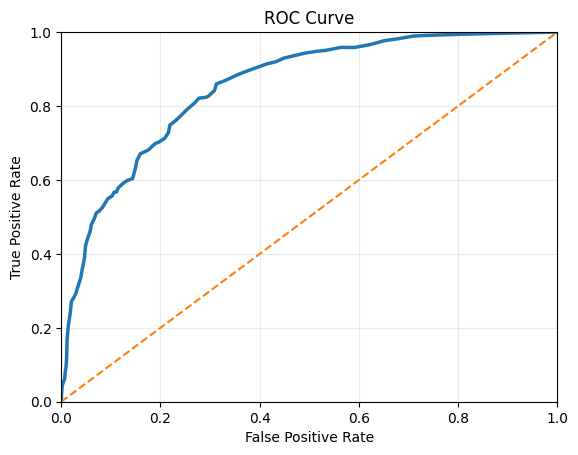

In [121]:
sns.lineplot(
    x=df_scores.FPR,
    y=df_scores.TPR,
    linewidth=2.5
)

plt.plot([0, 1], [0, 1], '--', linewidth=1.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.grid(alpha=0.25)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

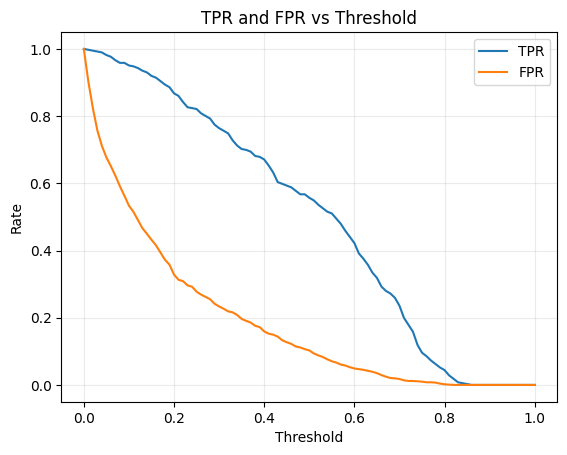

In [122]:
sns.lineplot(x=df_scores.threshold, y=df_scores.TPR, label="TPR")
sns.lineplot(x=df_scores.threshold, y=df_scores.FPR, label="FPR")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TPR and FPR vs Threshold")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

#### We prefer FRP curve as steep as possible.

### Random model

In [123]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size= len(y_val)).round(2)

In [124]:
y_rand

array([0.42, 0.72, 0.  , ..., 0.77, 0.33, 0.09], shape=(1409,))

#### Let's see the TPR and FPR for random model.

In [125]:
def tpr_fpr_dataframe(y_val, y_pred):
    thresholds = np.linspace(0, 1, 101)
    scores = []
    
    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
    
        predicted_positive = (y_pred >= t)
        predicted_negative = (y_pred < t)
    
        
        true_positives = (actual_positive & predicted_positive).sum()
        true_negatives = (actual_negative & predicted_negative).sum()
        false_positives = (actual_negative & predicted_positive).sum()
        false_negatives = (actual_positive & predicted_negative).sum()
    
        scores.append((t, true_positives, false_positives, false_negatives, true_negatives))

        df_scores = pd.DataFrame(scores)
        columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
        df_scores.columns = columns

        df_scores['TPR'] = df_scores.tp / (df_scores.tp + df_scores.fn)
        df_scores['FPR'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [126]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

In [127]:
df_rand[::10]

,threshold,tp,fp,fn,tn,TPR,FPR
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,349,924,37,99,0.904145,0.903226
20,0.2,310,827,76,196,0.803109,0.808407
30,0.3,278,728,108,295,0.720207,0.711632
40,0.4,240,627,146,396,0.621762,0.612903
50,0.5,203,523,183,500,0.525907,0.511241
60,0.6,164,418,222,605,0.424870,0.408602
70,0.7,119,296,267,727,0.308290,0.289345
80,0.8,81,213,305,810,0.209845,0.208211
90,0.9,45,106,341,917,0.116580,0.103617


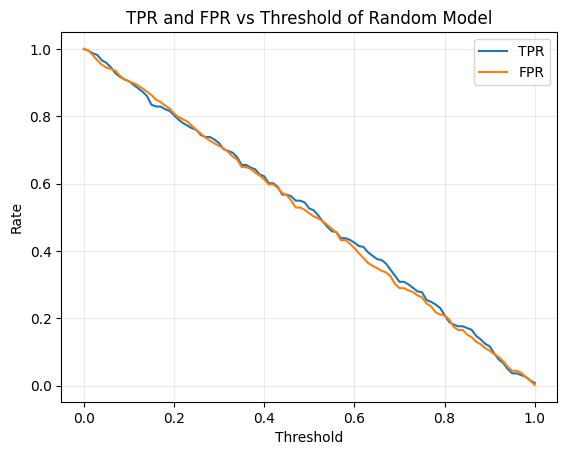

In [128]:
sns.lineplot(x=df_rand.threshold, y=df_rand.TPR, label="TPR")
sns.lineplot(x=df_rand.threshold, y=df_rand.FPR, label="FPR")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TPR and FPR vs Threshold of Random Model")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

### Ideal Model